# Question 2

On s'intéresse aux réseaux d'étudiants des universités de Caltech, MIT et Johns Hopkins.

In [1]:
import networkx as nx
import matplotlib.pyplot as plt

# On importe un graphe pour chacune des université
G_caltech = nx.read_gml('./db/Caltech36.gml')
G_mit = nx.read_gml('./db/MIT8.gml')
G_hopkins = nx.read_gml('./db/Johns Hopkins55.gml')

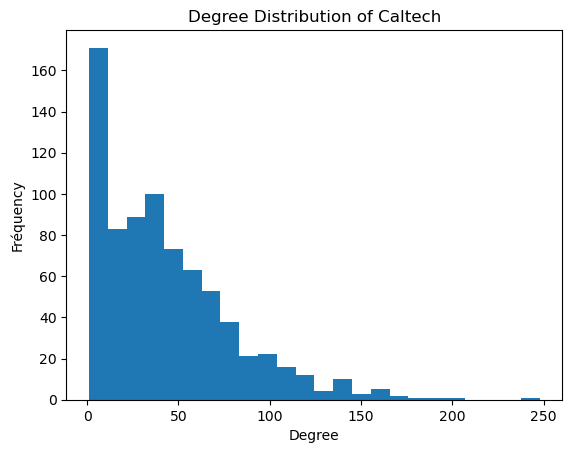

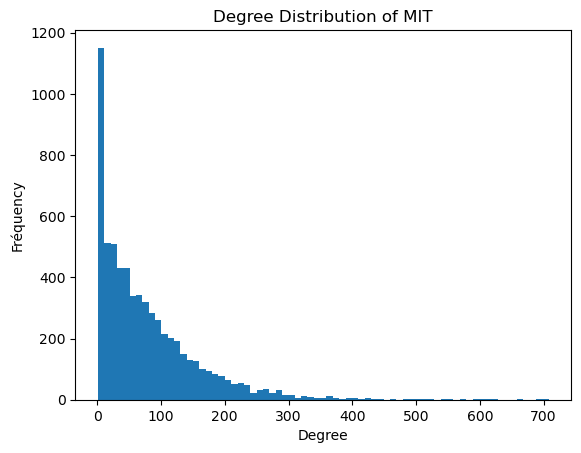

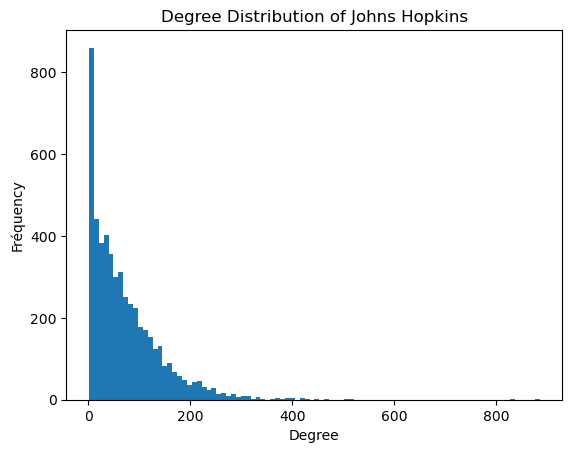

In [2]:
def plot_degree_distribution(g, title):
    degrees = [g.degree(n) for n in g.nodes()]
    plt.hist(degrees, bins='auto')
    plt.title(f"Degree Distribution of {title}")
    plt.xlabel('Degree')
    plt.ylabel('Fréquency')
    plt.show()

# On calcule les distributions des degrés pour chacune des universités
plot_degree_distribution(G_caltech, 'Caltech')
plot_degree_distribution(G_mit, 'MIT')
plot_degree_distribution(G_hopkins, 'Johns Hopkins')

## Interprétation

 - On a ici trois distributions de degré typiques des réseaux sociaux réels : fortement asymétriques, majorité de nœuds faiblement connectés, et une minorité ayant un degré élevé. Cela est cohérent avec le cadre de l'étude, vu que ce type de distribution est caractéristique des réseaux de type scale-free.

 - Ces trois graphes peuvent être vus comme des modèles du même phénomène social, mais à différentes échelles :
     - Caltech représente un réseau de petite taille, avec une distribution de degré plus compacte. La majorité des nœuds ont un faible degré, et seuls quelques-uns dépassent les 100 connexions.
     - MIT et surtout Johns Hopkins illustrent des réseaux de plus grande échelle, avec des distributions plus étalées. On y observe davantage de longues traînes, ce qui indique la présence d’un nombre significatif de nœuds très connectés (jusqu’à près de 900 pour Hopkins).
 - Cette différence d’échelle accentue les effets de croissance préférentielle : plus le réseau est grand, plus il a de chances de contenir des hubs très connectés. 

In [3]:
def compute_network_metrics(g, name):
    global_clust_coeff = nx.average_clustering(g)
    mean_local_clust_coeff = nx.transitivity(g)
    edge_density = nx.density(g)

    print(f"{name} Network Metrics:")
    print(f"Global Clustering Coefficient: {global_clust_coeff}")
    print(f"Mean Local Clustering Coefficient: {mean_local_clust_coeff}")
    print(f"Edge Density: {edge_density}\n")

# On calcule les trois données demandé pour chacune des universités
compute_network_metrics(G_caltech, 'Caltech')
compute_network_metrics(G_mit, 'MIT')
compute_network_metrics(G_hopkins, 'Johns Hopkins')

Caltech Network Metrics:
Global Clustering Coefficient: 0.40929439048517224
Mean Local Clustering Coefficient: 0.2912826901150874
Edge Density: 0.05640442132639792

MIT Network Metrics:
Global Clustering Coefficient: 0.271218741950132
Mean Local Clustering Coefficient: 0.18028845093502427
Edge Density: 0.012118119495041378

Johns Hopkins Network Metrics:
Global Clustering Coefficient: 0.26839307371293514
Mean Local Clustering Coefficient: 0.19316123901594015
Edge Density: 0.013910200162372396



## Interprétation 

 - Les réseaux sont très épars (faible densité d’arêtes), d'où peu de liens sont présents au vu du nombre de connexions : typique des réseaux sociaux réels à grande échelle.

 - On remarque que le réseau de Caltech a un coefficient de clustering global et local nettement plus élevé alors qu’il est bien plus petit : les amis d’un individu ont plus de chances d’être eux-mêmes amis entre eux.
     - La communauté de Caltech est donc contruite de pleins de petits groupes très connectés.

 - A l'inverse, on remarque que les réseaux du MIT et de Johns Hopkins, bien que beaucoup plus grands, ont un clustering plus faible : la structure globale est plus dispersée, avec moins de boucles locales.
     - Les communautés de MIT et Hopkins sont plus éclatée, avec des liens répartis à travers des sous-communautés plus lâches.

 - D'où Caltech illustre un réseau social plus serré et communautaire, tandis que MIT et Hopkins représentent des réseaux plus vastes et moins denses.

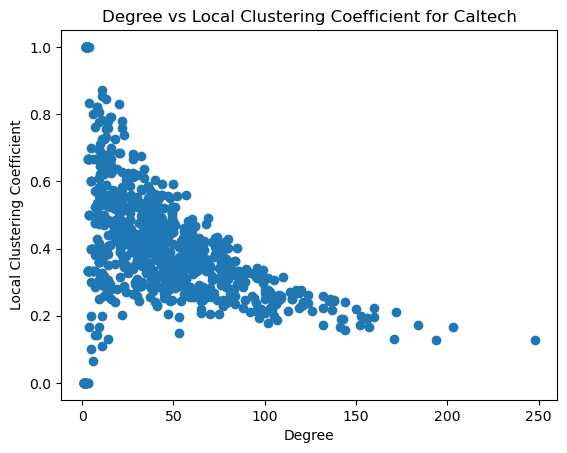

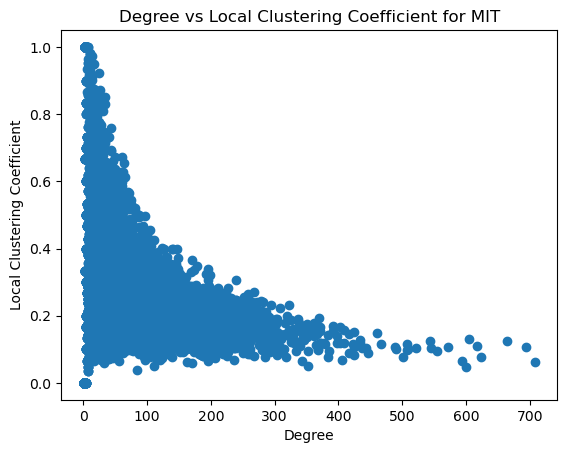

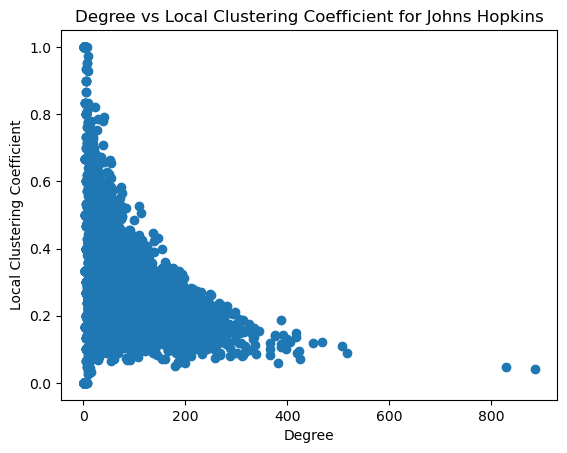

In [4]:
def plot_degree_vs_clustering(g, title):
    degrees = [g.degree(n) for n in g.nodes()]
    local_clust_coeffs = [nx.clustering(g, n) for n in g.nodes()]

    plt.scatter(degrees, local_clust_coeffs)
    plt.title(f"Degree vs Local Clustering Coefficient for {title}")
    plt.xlabel('Degree')
    plt.ylabel('Local Clustering Coefficient')
    plt.show()

# On trace le digramme du coefficient de clustering local en fonction du degré pour chacune des universités
plot_degree_vs_clustering(G_caltech, 'Caltech')
plot_degree_vs_clustering(G_mit, 'MIT')
plot_degree_vs_clustering(G_hopkins, 'Johns Hopkins')

## Interprétation

 - Dans les trois cas, on observe une tendance inverse entre le degré d’un noeud et son coefficient de clustering local. Les noeuds faiblement connectés ont souvent un clustering élevé, d'où "les amis de mes amis sont mes amis"

     - Caltech présente le grpahe le moins compact.
     - MIT présente une décroissance plus continue.
     - Johns Hopkins présente des points isolés.